In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path


# Seasonal Scope
- Original paper uses only summer months, because most incidents happen during the summer.
- However, this may not be the case for Essex. The paper references sources in which it indicates that an alternative approach is to make sub-models for each season. We must check if this is necessary.

In [2]:
incidents_df = pd.read_csv("./data/bronze/incidents/OutdoorFIres_2009_2025.csv")
incidents_df["CallDateID"] = pd.to_datetime(incidents_df["CallDateID"])

incidents_df["Year"] = incidents_df["CallDateID"].dt.year
incidents_df["Month"] = incidents_df["CallDateID"].dt.month

temp = incidents_df[["Year", "Month"]].copy()

def seasons(x):
    if x in [12, 1, 2]:
        return "WINTER"
    elif x in [3, 4, 5]:
        return "SPRING"
    elif x in [6, 7, 8]:
        return "SUMMER"
    elif x in [9, 10, 11]:
        return "FALL"
    else:
        return "?"


temp["Season"] = temp["Month"].apply(seasons)

C:\Users\rcorr\AppData\Local\Temp\ipykernel_2732\4123115399.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  incidents_df["CallDateID"] = pd.to_datetime(incidents_df["CallDateID"])


In [3]:
incidents_df["Year"].min(), incidents_df["Year"].max()

(np.int32(2009), np.int32(2025))

In [4]:
temp["Season"].value_counts() / len(temp)

Season
SUMMER    0.461324
SPRING    0.244064
FALL      0.218923
WINTER    0.075690
Name: count, dtype: float64

In [5]:
season_year_counts = temp.groupby(["Season", "Year"]).size().unstack(fill_value=0)
season_year_counts

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Season,,,,,,,,,,,,,,,,,
FALL,986,292,563,380,207,227,239,588,364,380,408,294,305,309,304,298,439
SPRING,510,524,771,433,277,326,353,317,647,260,507,486,419,413,281,221,594
SUMMER,1144,1125,658,398,744,549,774,670,636,1123,745,835,304,1727,653,661,1126
WINTER,41,109,172,199,127,99,99,144,146,161,184,138,93,150,140,136,138


In [6]:
pct_season_year_counts = 100 * season_year_counts / season_year_counts.sum(axis = 0)
pct_season_year_counts

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Season,,,,,,,,,,,,,,,,,
FALL,36.777322,14.243902,26.016636,26.950355,15.276753,18.900916,16.313993,34.205934,20.301171,19.750520,22.125813,16.771249,27.207850,11.889188,22.060958,22.644377,19.111885
SPRING,19.022753,25.560976,35.628466,30.709220,20.442804,27.144047,24.095563,18.440954,36.084774,13.513514,27.494577,27.723902,37.377342,15.890727,20.391872,16.793313,25.859817
SUMMER,42.670645,54.878049,30.406654,28.226950,54.907749,45.711907,52.832765,38.976149,35.471277,58.367983,40.401302,47.632630,27.118644,66.448634,47.387518,50.227964,49.020461
WINTER,1.529280,5.317073,7.948244,14.113475,9.372694,8.243131,6.757679,8.376963,8.142777,8.367983,9.978308,7.872219,8.296164,5.771451,10.159652,10.334347,6.007836


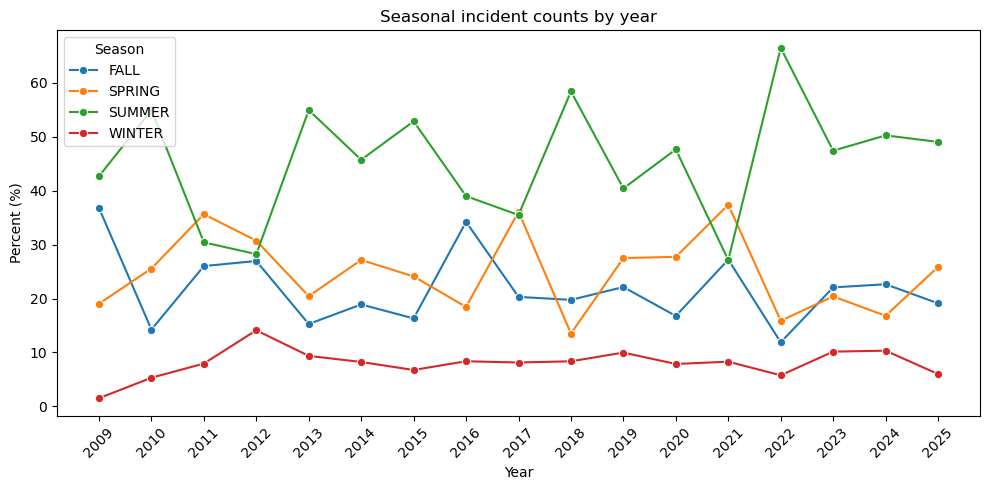

In [7]:
import matplotlib.pyplot as plt

df_long = pct_season_year_counts.reset_index().melt(id_vars="Season", var_name="Year", value_name="Percent (%)")
df_long["Year"] = df_long["Year"].astype(int)

plt.figure(figsize=(10,5))
sns.lineplot(data=df_long, x="Year", y="Percent (%)", hue="Season", marker="o")
plt.title("Seasonal incident counts by year")
plt.xticks(sorted(df_long["Year"].unique()), rotation=45)
plt.tight_layout()
plt.show()

In conclusion, it would be wrong to exclude the spring and fall months, since these three account for 93% of all incidents.

# Nans analysis

In [8]:
spring = pd.read_csv("./data/silver/model_datasets/dataset_clean_spring.csv")
summer = pd.read_csv("./data/silver/model_datasets/dataset_clean_summer.csv")
fall = pd.read_csv("./data/silver/model_datasets/dataset_clean_fall.csv")

In [9]:
BOUNDARY_PATH = Path("./data/silver/layers/boundary.shp")
MODEL_DATA_DIR = Path("./data/silver/model_datasets")
LAYERS_DIR = Path("./data/silver/layers")
OUTPUT_DIR = Path("./figures")
OUTPUT_DIR.mkdir(exist_ok=True)
 
SEASONS = ["spring", "summer", "fall"]
 
# Reference raster to reconstruct spatial shape
REF_RASTER = LAYERS_DIR / "topo_elevation.tif"
 
FEATURE_COLS = [
    "elevation", "slope", "aspect",
    "d_roads", "d_rivers", "d_activity", "d_fires",
    "tas", "tasmax", "tasmin", "rainfall", "sfcWind", "hurs",
    "ndvi",
]
 
boundary = gpd.read_file(BOUNDARY_PATH).to_crs("EPSG:27700")

In [10]:
def make_nan_mask_from_csv(season: str) -> tuple[np.ndarray, rasterio.transform.Affine]:
    """
    Returns:
        nan_mask  - 2-D bool array (height x width), True where ≥1 feature is NaN
        transform - affine transform for the reference raster
    """
    df = pd.read_csv(MODEL_DATA_DIR / f"dataset_clean_{season}.csv")
 
    has_nan = df[FEATURE_COLS].isna().any(axis=1)

    with rasterio.open(REF_RASTER) as src:
        ref_data  = src.read(1)
        transform = src.transform
        height, width = ref_data.shape
 
    valid_mask = ~np.isnan(ref_data)
    n_valid = valid_mask.sum()
 
    if len(df) != n_valid:
        print(f"[{season}] WARNING: CSV rows ({len(df)}) ≠ valid pixels ({n_valid}). "
              "Mask reconstruction may be off.")
 
    grid = np.full((height, width), -1, dtype=np.int8)
    grid[valid_mask] = has_nan.values.astype(np.int8)
 
    return grid, transform

Saved → figures\nan_coverage_map.png


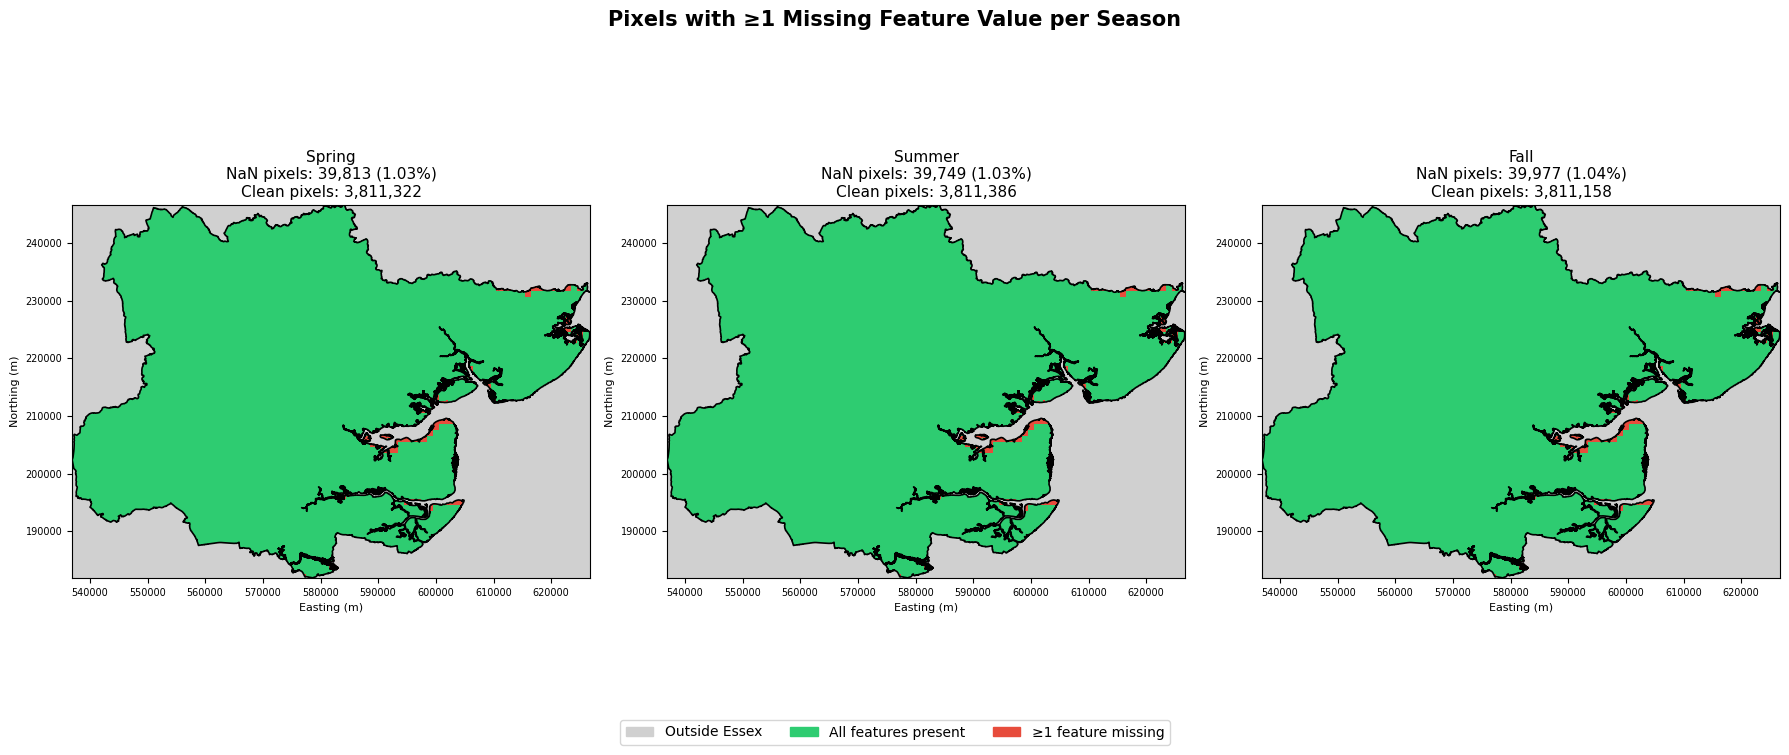

In [11]:
fig, axes = plt.subplots(1, len(SEASONS), figsize=(18, 7))
fig.suptitle(
    "Pixels with ≥1 Missing Feature Value per Season",
    fontsize=15, fontweight="bold", y=1.02,
)
 
cmap = mcolors.ListedColormap(["#d0d0d0", "#2ecc71", "#e74c3c"])
norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

for ax, season in zip(axes, SEASONS):
    grid, transform = make_nan_mask_from_csv(season)
 
    bounds = rasterio.transform.array_bounds(grid.shape[0], grid.shape[1], transform)
    extent = [bounds[0], bounds[2], bounds[1], bounds[3]]   # left, right, bottom, top
 
    im = ax.imshow(grid, extent=extent, cmap=cmap, norm=norm,
                   interpolation="nearest", origin="upper")
    boundary.boundary.plot(ax=ax, color="black", linewidth=1.2)
 
    # Stats annotation
    inside = grid >= 0
    n_nan  = (grid == 1).sum()
    n_ok   = (grid == 0).sum()
    pct_nan = 100 * n_nan / inside.sum() if inside.sum() > 0 else 0
 
    ax.set_title(
        f"{season.capitalize()}\n"
        f"NaN pixels: {n_nan:,} ({pct_nan:.2f}%)\n"
        f"Clean pixels: {n_ok:,}",
        fontsize=11,
    )
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8)
    ax.tick_params(labelsize=7)
# Shared legend
patches = [
    mpatches.Patch(color="#d0d0d0", label="Outside Essex"),
    mpatches.Patch(color="#2ecc71", label="All features present"),
    mpatches.Patch(color="#e74c3c", label="≥1 feature missing"),
]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))
 
plt.tight_layout()
out_path = OUTPUT_DIR / "nan_coverage_map.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

In [12]:
# ── Per-feature NaN breakdown table (all seasons) ────────────────────────────
print("\n── NaN % by feature and season ──")
rows = []
for season in SEASONS:
    df = pd.read_csv(MODEL_DATA_DIR / f"dataset_clean_{season}.csv")
    pct = (df[FEATURE_COLS].isna().sum() / len(df) * 100).rename(season)
    rows.append(pct)
 
summary = pd.DataFrame(rows).T
summary.columns = [s.capitalize() for s in SEASONS]
summary["Max"] = summary.max(axis=1)
print(summary.round(3).to_string())


── NaN % by feature and season ──
            Spring  Summer   Fall    Max
elevation    0.000   0.000  0.000  0.000
slope        0.000   0.000  0.000  0.000
aspect       0.000   0.000  0.000  0.000
d_roads      0.000   0.000  0.000  0.000
d_rivers     0.000   0.000  0.000  0.000
d_activity   0.000   0.000  0.000  0.000
d_fires      0.000   0.000  0.000  0.000
tas          1.009   1.009  1.009  1.009
tasmax       1.009   1.009  1.009  1.009
tasmin       1.009   1.009  1.009  1.009
rainfall     1.009   1.009  1.009  1.009
sfcWind      1.009   1.009  1.009  1.009
hurs         1.009   1.009  1.009  1.009
ndvi         0.048   0.046  0.055  0.055


In [13]:
# ── Which features drive the remaining NaNs? ─────────────────────────────────
print("\n── Top NaN contributors (Summer as representative) ──")
df_summer = pd.read_csv(MODEL_DATA_DIR / "dataset_clean_summer.csv")
 
# For pixels that have ANY NaN, which features are responsible?
nan_rows = df_summer[df_summer[FEATURE_COLS].isna().any(axis=1)]
feature_nan_pct = (nan_rows[FEATURE_COLS].isna().sum() / len(nan_rows) * 100).sort_values(ascending=False)
print(feature_nan_pct.round(1).to_string())
print(f"\nTotal NaN pixels (summer): {len(nan_rows):,} / {len(df_summer):,} "
      f"({100*len(nan_rows)/len(df_summer):.2f}%)")


── Top NaN contributors (Summer as representative) ──
sfcWind       97.8
hurs          97.8
rainfall      97.8
tasmin        97.8
tasmax        97.8
tas           97.8
ndvi           4.5
d_rivers       0.0
d_activity     0.0
aspect         0.0
slope          0.0
elevation      0.0
d_roads        0.0
d_fires        0.0

Total NaN pixels (summer): 39,749 / 3,851,135 (1.03%)
